<a href="https://colab.research.google.com/github/nguyentrungtin123/thuchanh_deeplearning/blob/main/th_deeplearning_buoi04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3. THỰC HÀNH VỀ RNN VÀ LSTM

2.1. Nạp thư viện

In [10]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

2.2. Nạp dataset

In [11]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


2.3. Xây dựng mô hình Autoencoder

In [12]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

2.4. Huấn luyện mô hình

In [13]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0114 - loss: 0.2755 - val_accuracy: 0.0130 - val_loss: 0.1911
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0140 - loss: 0.1712 - val_accuracy: 0.0120 - val_loss: 0.1541
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0104 - loss: 0.1446 - val_accuracy: 0.0090 - val_loss: 0.1338
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0108 - loss: 0.1286 - val_accuracy: 0.0095 - val_loss: 0.1214
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0105 - loss: 0.1182 - val_accuracy: 0.0107 - val_loss: 0.1130
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0106 - loss: 0.1111 - val_accuracy: 0.0107 - val_loss: 0.1069
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0112 - loss: 0.1061 - val_accuracy: 0.0122 - val_loss: 0.1027
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0115 - loss: 0.1024 - val_accu

2.5. Dự báo loại ảnh sử dụng Autoencoder

In [14]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


2.6. Hiển thị ảnh từ mô hình Autoencoder


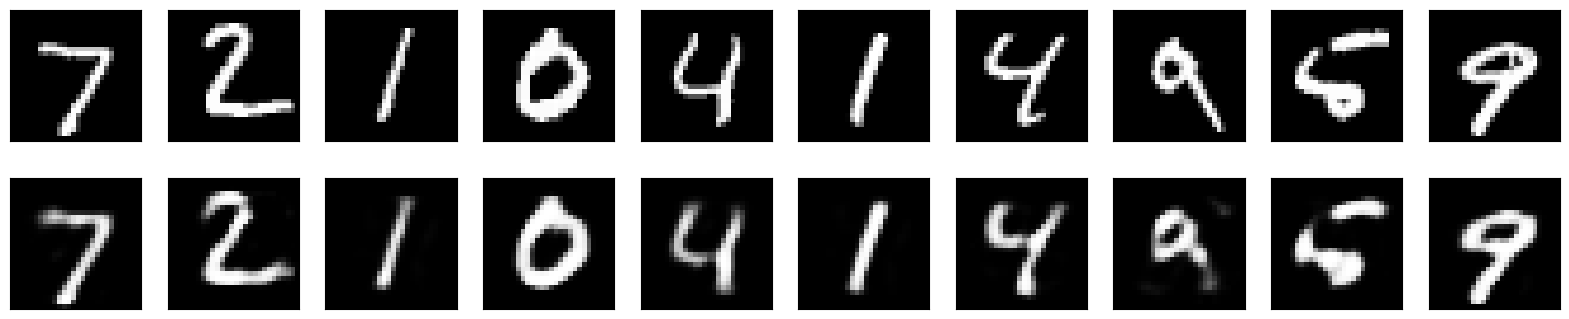

In [15]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

3.1. Thêm L1

In [16]:
from keras import regularizers

encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256,
                verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0140 - loss: 0.6551 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0145 - loss: 0.3739 - 

3.2. Thêm layers

In [17]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(32,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0108 - loss: 0.2528 - val_accuracy: 0.0116 - val_loss: 0.1655
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0096 - loss: 0.1480 - val_accuracy: 0.0098 - val_loss: 0.1342
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0116 - loss: 0.1290 - val_accuracy: 0.0120 - val_loss: 0.1217
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0114 - loss: 0.1189 - val_accuracy: 0.0104 - val_loss: 0.1132
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0098 - loss: 0.1118 - val_accuracy: 0.0094 - val_loss: 0.1075
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0104 - loss: 0.1068 - val_accuracy: 0.0102 - val_loss: 0.1032
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0109 - loss: 0.1030 - val_accuracy: 0.0111 - val_loss: 0.1002
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0117 - loss: 0.1002 - val_accu

1: Cài đặt Autoencoder nhận dạng ảnh trên bộ dataset CIFAR10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
X_train shape: (50000, 3072)
X_test shape: (10000, 3072)
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.0021 - loss: 0.6363 - val_accuracy: 0.0043 - val_loss: 0.6165
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.0040 - loss: 0.6091 - val_accuracy: 0.0074 - val_loss: 0.6043
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.0045 - loss: 0.6004 - val_accuracy: 0.0057 - val_loss: 0.6003
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.0053 - loss: 0.5944 - val_accuracy: 0.0055 - val_loss: 0.5918
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.0053 - loss: 0.5904 - val_accuracy: 0.0054 - val_loss: 0.5888
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.0062 - loss: 0.5871 - val_accuracy: 0.0077 - val_loss: 0.5858
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.0059 - loss: 0.5847 - val_accuracy: 0.0061

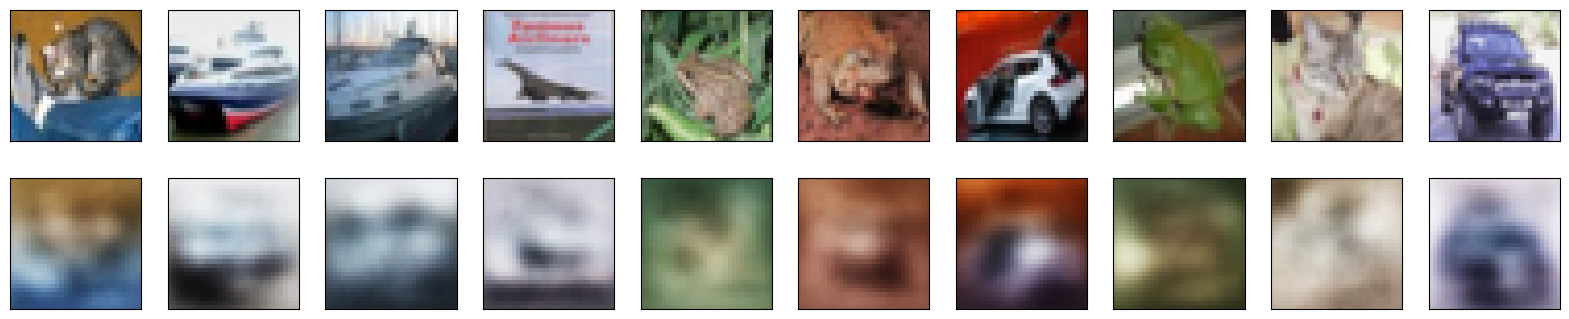

In [18]:
import numpy as np
import keras
from keras import layers
from keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)

encoding_dim = 128

input_img = keras.Input(shape=(3072,))

encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

decoded = layers.Dense(3072, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(32, 32, 3))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(32, 32, 3))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Câu 2 & Câu 4: Cài đặt Autoencoder để nhận dạng ảnh

Thu muc /content/dataset_images chua ton tai. Tao thu muc mau de chay demo.
Train shape: (80, 12288)
Test shape: (20, 12288)
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.0000e+00 - loss: 0.0837 - val_accuracy: 0.0000e+00 - val_loss: 0.0835
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 0.0000e+00 - loss: 0.0833 - val_accuracy: 0.0000e+00 - val_loss: 0.0836
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.0000e+00 - loss: 0.0829 - val_accuracy: 0.0000e+00 - val_loss: 0.0840
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.0000e+00 - loss: 0.0825 - val_accuracy: 0.0000e+00 - val_loss: 0.0843
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.0000e+00 - loss: 0.0823 - val_accuracy: 0.0000e+00 - val_loss: 0.0843
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.0000e+00 - loss: 0.0822 - val_accuracy: 0.0000e+00 - val_loss: 0.0843
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.0000e+0

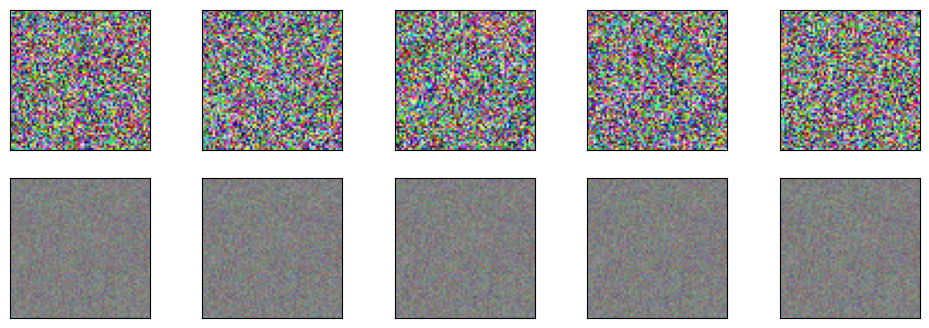

In [19]:
import os
import cv2
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

def load_custom_dataset(dataset_path, image_size=(64, 64)):
    data = []
    if not os.path.exists(dataset_path):
        print(f"Thu muc {dataset_path} chua ton tai. Tao thu muc mau de chay demo.")
        os.makedirs(dataset_path, exist_ok=True)
        return np.random.rand(100, image_size[0] * image_size[1] * 3).astype('float32')

    for img_name in os.listdir(dataset_path):
        try:
            img_path = os.path.join(dataset_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, image_size)
                data.append(img.flatten())
        except Exception as e:
            print(f"Loi doc anh {img_name}: {e}")

    return np.array(data).astype('float32') / 255.

dataset_path = '/content/dataset_images'
dataset = load_custom_dataset(dataset_path)

split_idx = int(len(dataset) * 0.8)
x_train = dataset[:split_idx]
x_test = dataset[split_idx:]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

input_dim = x_train.shape[1]
encoding_dim = 256

input_img = keras.Input(shape=(input_dim,))

encoded = layers.Dense(512, activation='relu')(input_img)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decoded = layers.Dense(512, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-2](encoded_input)
decoder_layer = autoencoder.layers[-1](decoder_layer)
decoder = keras.Model(encoded_input, decoder_layer)

autoencoder.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

if len(x_train) > 0:
    autoencoder.fit(x_train, x_train,
                    epochs=30,
                    batch_size=32,
                    shuffle=True,
                    validation_data=(x_test, x_test))

if len(x_test) > 0:
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = decoder.predict(encoded_imgs)

    n = min(5, len(x_test))
    plt.figure(figsize=(12, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(64, 64, 3))
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(64, 64, 3))
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

3: Hãy viết chương trình cài đặt Autoencoder để nhận dạng ảnh Fashion-MNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 784)
X_test shape: (10000, 784)
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.0087 - loss: 0.3785 - val_accuracy: 0.0170 - val_loss: 0.3181
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.0132 - loss: 0.3097 - val_accuracy: 0.0135 - val_loss: 0.3068
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0137 - loss: 0.3021 - val_accuracy: 0.0122 - val_loss: 0.3037
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0121 - loss: 0.2978 - val_accuracy: 0.0141 - val_loss: 0.2984
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0136 - loss: 0.2947 - val_accuracy: 0.0181 - val_loss: 0.2955
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0154 - loss: 0.2923 - val_accuracy: 0.0169 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


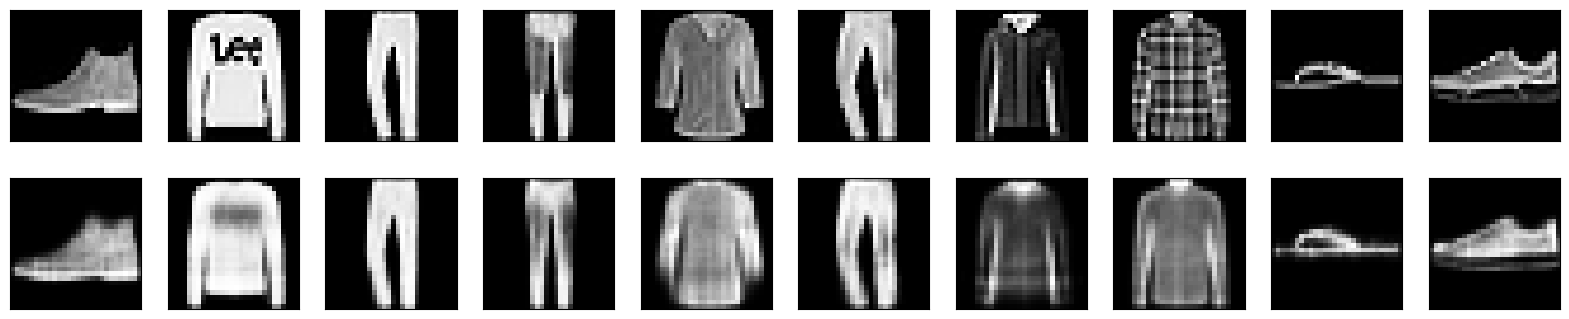

In [20]:
import numpy as np
import keras
from keras import layers
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)

encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))

decoder_layer = autoencoder.layers[-3](encoded_input)
decoder_layer = autoencoder.layers[-2](decoder_layer)
decoder_layer = autoencoder.layers[-1](decoder_layer)
decoder = keras.Model(encoded_input, decoder_layer)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()